# Exploring the structure annotations

Browse and chart the finished annotation tables. Everything is read from the Parquet files in `data/annotated/`, which are the source of truth; the CSV exports are only copies.

| DataFrame | One row per |
|---|---|
| `df_samples` | Starrydata sample (composition + paper + structure assignment) |
| `df_comps` | distinct composition, with sample and paper counts |
| `df_review` | host system still waiting for a paper check |

Run the cells top to bottom. Charts are interactive: hover for values, drag to zoom, double-click to reset.

In [1]:
import json
from pathlib import Path

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 80)

ROOT = Path.cwd()
while not (ROOT / 'data' / 'annotated').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
ANN = ROOT / 'data' / 'annotated'

df_samples = pd.read_parquet(ANN / 'df_annotated_samples.parquet')
df_comps = pd.read_parquet(ANN / 'df_annotated_compositions.parquet')
df_review = pd.read_parquet(ANN / 'validation' / 'needs_review.parquet')

df_samples['structural_class'] = df_samples['structural_class'].fillna('(unassigned)')
df_comps['structural_class'] = df_comps['structural_class'].fillna('(unassigned)')
df_samples['year'] = pd.to_numeric(df_samples['year'], errors='coerce')

# Chart style: one blue for single-series bars, an ordered blue ramp for confidence,
# light grid, thin bars with a small gap.
BLUE = '#2a78d6'
CONF_ORDER = ['high', 'medium', 'low']
CONF_COLORS = {'high': '#1c5cab', 'medium': '#5598e7', 'low': '#86b6ef'}
pio.templates['annot'] = go.layout.Template(layout=dict(
    font=dict(family='system-ui, -apple-system, Segoe UI, sans-serif', size=13, color='#0b0b0b'),
    paper_bgcolor='#fcfcfb', plot_bgcolor='#fcfcfb',
    xaxis=dict(gridcolor='#e7e6e2', zeroline=False, linecolor='#c9c8c2', tickfont=dict(color='#52514e')),
    yaxis=dict(gridcolor='#e7e6e2', zeroline=False, linecolor='#c9c8c2', tickfont=dict(color='#52514e')),
    colorway=[BLUE], bargap=0.25, hoverlabel=dict(bgcolor='white', font_size=12),
    margin=dict(l=10, r=20, t=60, b=40), legend=dict(title_text=''),
))
pio.templates.default = 'plotly_white+annot'

print(f'{len(df_samples):,} samples · {len(df_comps):,} compositions · '
      f'{df_samples.host_system.nunique():,} host systems · {df_samples.prototype_id.nunique():,} prototypes')

52,027 samples · 27,456 compositions · 3,648 host systems · 410 prototypes


## 1. Overview

In [2]:
def share(s):
    return (s.value_counts(dropna=False).rename('samples').to_frame()
            .assign(percent=lambda df: (100 * df.samples / df.samples.sum()).round(1)))

display(share(df_samples.confidence).loc[CONF_ORDER])
display(share(df_samples.determined_at))

,samples,percent
confidence,,
high,42418,81.5
medium,8914,17.1
low,695,1.3


,samples,percent
determined_at,,
host,32903,63.2
composition,14013,26.9
sample_required,5111,9.8


`determined_at` says at what level the structure was fixed: **host** (one structure for the whole host system), **composition** (the host was split by composition), or **sample_required** (the composition alone can't decide it, e.g. MIXED phases).

## 2. Samples by structural class

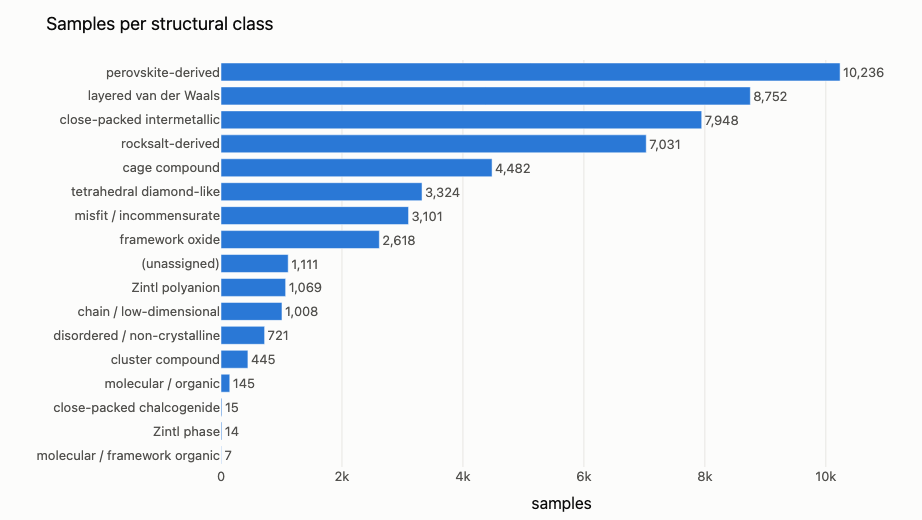

In [3]:
s_by_class = df_samples.structural_class.value_counts().sort_values()
fig = px.bar(s_by_class, orientation='h', labels={'value': 'samples', 'structural_class': ''},
             title='Samples per structural class', text_auto=',')
fig.update_traces(marker_color=BLUE, textposition='outside', textfont_color='#52514e',
                  hovertemplate='%{y}<br>%{x:,} samples<extra></extra>')
fig.update_layout(showlegend=False, height=520, xaxis_range=[0, s_by_class.max() * 1.1])
fig.show()

## 3. Most common structure prototypes

Change `TOP_N` to see more.

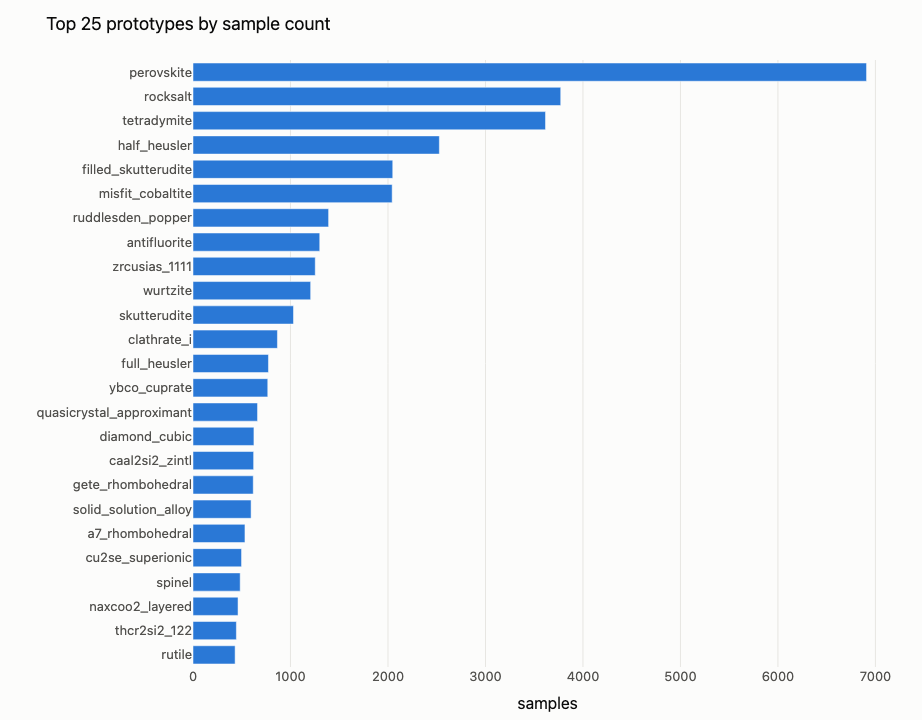

In [4]:
TOP_N = 25
df_proto = (df_samples.groupby(['prototype_id', 'structural_class'])
            .agg(samples=('SID', 'size'), hosts=('host_system', 'nunique'), papers=('DOI', 'nunique'))
            .reset_index().nlargest(TOP_N, 'samples').sort_values('samples'))
fig = px.bar(df_proto, x='samples', y='prototype_id', orientation='h',
             hover_data={'structural_class': True, 'hosts': True, 'papers': True, 'prototype_id': False},
             labels={'prototype_id': ''}, title=f'Top {TOP_N} prototypes by sample count')
fig.update_traces(marker_color=BLUE)
fig.update_layout(height=24 * TOP_N + 120)
fig.show()

## 4. How confident are the assignments, per class?

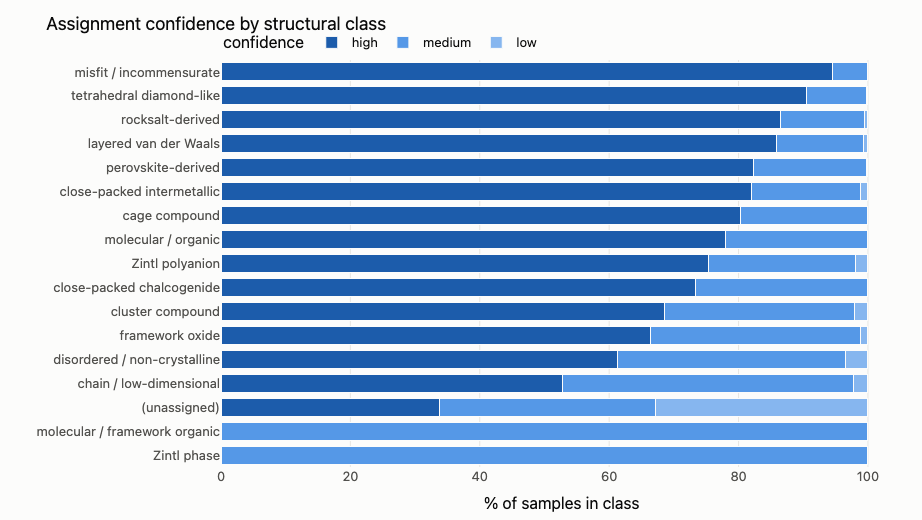

In [5]:
df_conf = df_samples.groupby(['structural_class', 'confidence']).size().rename('samples').reset_index()
df_conf['percent'] = 100 * df_conf.samples / df_conf.groupby('structural_class').samples.transform('sum')
order = (df_conf[df_conf.confidence == 'high'].set_index('structural_class').percent
         .reindex(df_conf.structural_class.unique()).fillna(0).sort_values().index.tolist())
fig = px.bar(df_conf, x='percent', y='structural_class', color='confidence', orientation='h',
             category_orders={'confidence': CONF_ORDER, 'structural_class': order[::-1]},
             color_discrete_map=CONF_COLORS, custom_data=['confidence', 'samples'],
             labels={'percent': '% of samples in class', 'structural_class': ''},
             title='Assignment confidence by structural class')
fig.update_traces(marker_line_color='#fcfcfb', marker_line_width=1,
                  hovertemplate='%{y}<br>%{customdata[0]}: %{x:.1f}% (%{customdata[1]:,} samples)<extra></extra>')
fig.update_layout(barmode='stack', height=520, legend=dict(orientation='h', y=1.08, x=0))
fig.show()

## 5. Samples over publication year

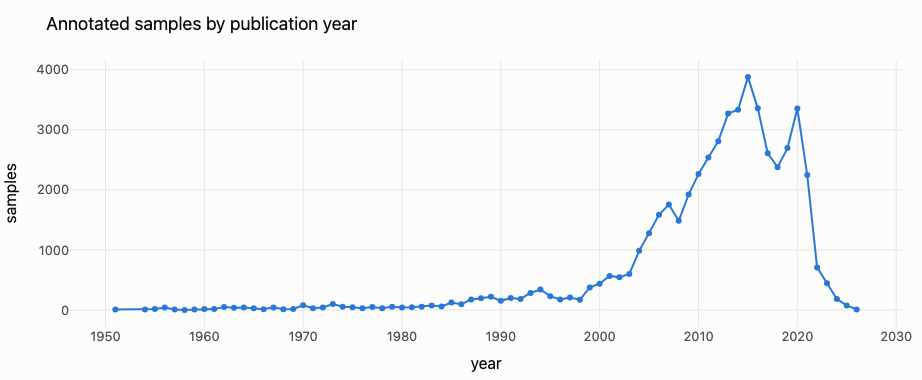

391 samples have no year


In [6]:
df_per_year = df_samples.dropna(subset=['year']).groupby('year').size().rename('samples').reset_index()
fig = px.line(df_per_year, x='year', y='samples', markers=True, title='Annotated samples by publication year')
fig.update_traces(line_color=BLUE, line_width=2, marker_size=6,
                  hovertemplate='%{x:.0f}: %{y:,} samples<extra></extra>')
fig.update_layout(hovermode='x', height=380)
fig.show()
print(f"{df_samples.year.isna().sum():,} samples have no year")

## 6. Dopants

Most frequent dopant elements across samples (a sample with several dopants counts once per element).

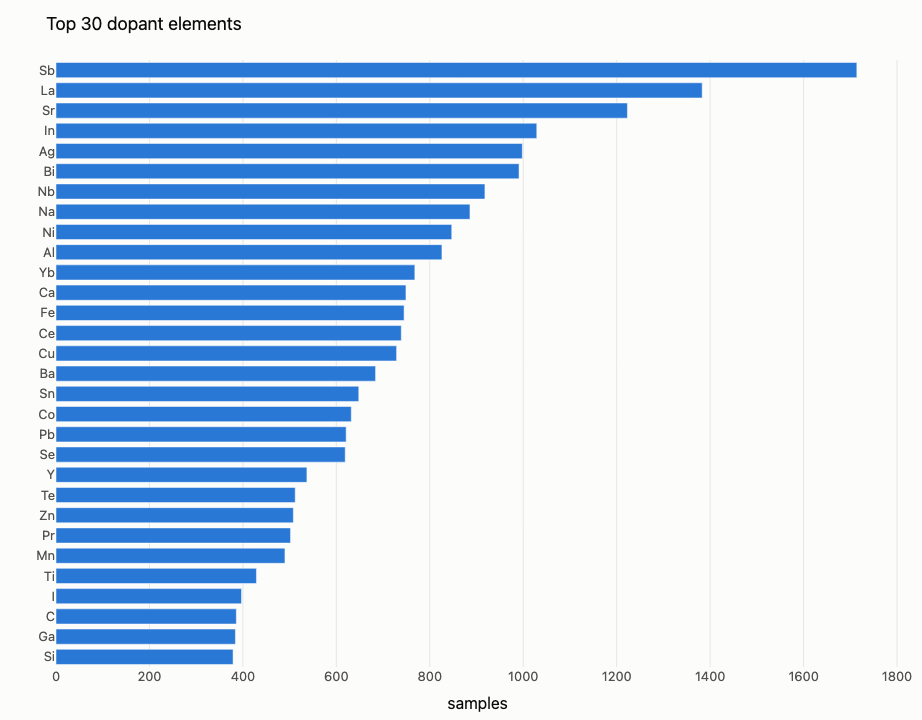

In [7]:
s_dopants = (df_samples.dopant_elements.dropna().str.split(r'[,;\s]+').explode()
             .loc[lambda s: s.str.len() > 0].value_counts().head(30).sort_values())
fig = px.bar(s_dopants, orientation='h', labels={'value': 'samples', 'dopant_elements': ''},
             title='Top 30 dopant elements')
fig.update_traces(marker_color=BLUE, hovertemplate='%{y}: %{x:,} samples<extra></extra>')
fig.update_layout(showlegend=False, height=720)
fig.show()

## 7. What still needs a paper check

The same list as `validation/needs_review.md`, as a table you can sort and filter.

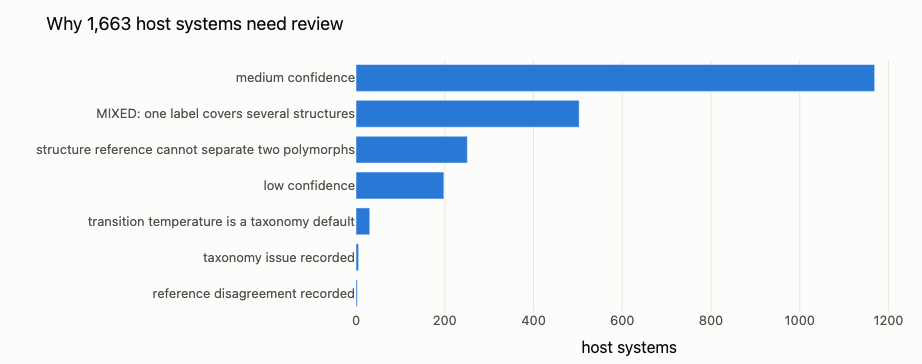

,host_system,prototype_id,confidence,n_samples,chunk,reasons
0,Bi-Sb-Te,tetradymite,high,1473,1,structure reference cannot separate two polymorphs
1,O-Sr-Ti,perovskite,high,1338,1,structure reference cannot separate two polymorphs
2,Bi-Se-Te,tetradymite,high,634,1,structure reference cannot separate two polymorphs
3,Mg-Si,antifluorite,high,453,1,structure reference cannot separate two polymorphs
4,Ge-Te,gete_rhombohedral,high,450,1,"transition at ~700 K is a taxonomy default, not read from a paper"
5,La-Mn-O,perovskite,high,377,1,structure reference cannot separate two polymorphs
6,C,graphite_layered,medium,369,1,medium confidence; taxonomy issue recorded
7,O-Ti,rutile,low,367,1,low confidence
8,Co-Na-O,naxcoo2_layered,medium,342,1,medium confidence
9,Co-La-O,perovskite,high,327,1,structure reference cannot separate two polymorphs


In [8]:
s_reasons = df_review.reasons.str.split(';').explode().str.strip()
s_reasons = (s_reasons.str.replace(r'^MIXED.*', 'MIXED: one label covers several structures', regex=True)
             .str.replace(r'^transition at .*', 'transition temperature is a taxonomy default', regex=True)
             .str.replace(r'\s*\(.*\)', '', regex=True)
             .value_counts().sort_values())
fig = px.bar(s_reasons, orientation='h', labels={'value': 'host systems', 'reasons': ''},
             title=f'Why {len(df_review):,} host systems need review')
fig.update_traces(marker_color=BLUE, hovertemplate='%{y}: %{x:,} hosts<extra></extra>')
fig.update_layout(showlegend=False, height=32 * len(s_reasons) + 140)
fig.show()

df_review.sort_values('n_samples', ascending=False).head(30)

## 8. Look up a host system, prototype or composition

Edit the argument and re-run. Matching is exact for hosts/prototypes and case-insensitive substring for compositions.

In [9]:
def host(name):
    df_host = df_samples[df_samples.host_system == name]
    print(f'{name}: {len(df_host):,} samples, {df_host.composition.nunique():,} compositions, '
          f'{df_host.DOI.nunique():,} papers')
    display(df_host.groupby(['prototype_id', 'confidence', 'determined_at']).size().rename('samples')
             .sort_values(ascending=False).to_frame())
    return (df_comps[df_comps.host_system == name]
            [['composition', 'prototype_id', 'confidence', 'split_rule', 'spacegroup_number', 'mp_id',
              'dopant_elements', 'n_samples', 'n_papers']]
            .sort_values('n_samples', ascending=False))


def prototype(pid):
    df_pid = df_samples[df_samples.prototype_id == pid]
    print(f'{pid}: {len(df_pid):,} samples across {df_pid.host_system.nunique():,} host systems')
    return (df_pid.groupby('host_system').agg(samples=('SID', 'size'), papers=('DOI', 'nunique'),
                                              confidence=('confidence', lambda s: s.mode().iat[0]))
            .sort_values('samples', ascending=False))


def find(text):
    mask = df_samples.composition.str.contains(text, case=False, regex=False, na=False)
    return df_samples.loc[mask, ['composition', 'host_system', 'prototype_id', 'confidence',
                                 'form', 'year', 'DOI', 'title']]


host('Bi-Te')

Bi-Te: 955 samples, 292 compositions, 324 papers


,,,samples
prototype_id,confidence,determined_at,
tetradymite,high,composition,891
homologous_tetradymite,high,composition,64


,composition,prototype_id,confidence,split_rule,spacegroup_number,mp_id,dopant_elements,n_samples,n_papers
1,Bi2Te3,tetradymite,high,fallback,166.0,mp-34202,,446,227
90,Bi2Te2.85Se0.15,tetradymite,high,fallback,166.0,mp-34202,Se,30,13
311,BiTe,homologous_tetradymite,high,rule 1,166.0,mp-34202,,12,6
390,Bi0.46Te0.54,homologous_tetradymite,high,rule 1,166.0,mp-34202,,10,3
394,Bi2Te2.8Se0.2,tetradymite,high,fallback,166.0,mp-34202,Se,10,7
...,...,...,...,...,...,...,...,...,...
21559,Ni0.15Bi2Te3,tetradymite,high,fallback,166.0,mp-34202,,1,1
21562,Ni0.1Bi2Te3,tetradymite,high,fallback,166.0,mp-34202,,1,1
23329,Sm0.2Bi1.8Te3,tetradymite,high,fallback,166.0,mp-34202,,1,1
25039,Te9BiTe6,tetradymite,high,fallback,166.0,mp-34202,,1,1


In [10]:
prototype('half_heusler').head(20)

half_heusler: 2,527 samples across 164 host systems


,samples,papers,confidence
host_system,,,
Ni-Sn-Ti,305,65,high
Ni-Sn-Zr,280,68,high
Hf-Ni-Sn-Zr,261,58,high
Hf-Ni-Sn-Ti-Zr,179,41,high
Co-Sb-Ti,135,36,high
Fe-Nb-Sb,98,25,high
Ni-Sn-Ti-Zr,74,20,high
Co-Nb-Sn,73,17,high
Co-Sb-Zr,65,24,high


In [11]:
find('Mg2Si').head(20)

,composition,host_system,prototype_id,confidence,form,year,DOI,title
332,Bi0.02(Mg2Si)0.98,Mg-Si,antifluorite,high,Bulk,2014.0,10.1016/j.actamat.2014.04.007,Simultaneous enhancement of mechanical and thermoelectric properties of poly...
333,Al0.02(Mg2Si)0.98,Mg-Si,antifluorite,high,Bulk,2014.0,10.1016/j.actamat.2014.04.007,Simultaneous enhancement of mechanical and thermoelectric properties of poly...
346,Mg2Si0.54Sn0.4Ge0.05Bi0.01,Mg-Si-Sn,antifluorite,high,Bulk,2014.0,10.1016/j.actamat.2014.04.060,Thermoelectric properties of highly efficient Bi-doped Mg2Si1−x−ySnxGey mate...
347,Mg2Si0.525Sn0.4Ge0.05Bi0.025,Mg-Si-Sn,antifluorite,high,Bulk,2014.0,10.1016/j.actamat.2014.04.060,Thermoelectric properties of highly efficient Bi-doped Mg2Si1−x−ySnxGey mate...
348,Mg2Si0.52Sn0.4Ge0.05Bi0.03,Mg-Si-Sn,antifluorite,high,Bulk,2014.0,10.1016/j.actamat.2014.04.060,Thermoelectric properties of highly efficient Bi-doped Mg2Si1−x−ySnxGey mate...
349,Mg2Si0.515Sn0.4Ge0.05Bi0.035,Mg-Si-Sn,antifluorite,high,Bulk,2014.0,10.1016/j.actamat.2014.04.060,Thermoelectric properties of highly efficient Bi-doped Mg2Si1−x−ySnxGey mate...
350,Mg2Si0.55Sn0.4Ge0.05Bi0,Mg-Si-Sn,antifluorite,high,Bulk,2014.0,10.1016/j.actamat.2014.04.060,Thermoelectric properties of highly efficient Bi-doped Mg2Si1−x−ySnxGey mate...
351,Mg2Si0.5325Sn0.4Ge0.05Bi0.0175,Mg-Si-Sn,antifluorite,high,Bulk,2014.0,10.1016/j.actamat.2014.04.060,Thermoelectric properties of highly efficient Bi-doped Mg2Si1−x−ySnxGey mate...
352,Mg2Si0.53Sn0.4Ge0.05Bi0.02,Mg-Si-Sn,antifluorite,high,Bulk,2014.0,10.1016/j.actamat.2014.04.060,Thermoelectric properties of highly efficient Bi-doped Mg2Si1−x−ySnxGey mate...
353,Mg2Si0.5275Sn0.4Ge0.05Bi0.0225,Mg-Si-Sn,antifluorite,high,Bulk,2014.0,10.1016/j.actamat.2014.04.060,Thermoelectric properties of highly efficient Bi-doped Mg2Si1−x−ySnxGey mate...


## 9. Phases and dopants of one sample

`phases_json` and `dopants_json` hold the detailed per-sample structure; this unpacks them.

In [12]:
def detail(sid_or_row=0):
    s_row = df_samples.iloc[sid_or_row] if isinstance(sid_or_row, int) else sid_or_row
    print(s_row.composition, '·', s_row.host_system, '·', s_row.DOI)
    display(pd.DataFrame(json.loads(s_row.phases_json or '[]')))
    display(pd.DataFrame(json.loads(s_row.dopants_json or '[]')))

detail(df_samples[df_samples.n_dopants > 1].iloc[0])

Pb1.0015Zn0.01Te1.01I0.003 · Pb-Te · 10.1021/am405410e


,prototype_id,spacegroup_number,mp_id,t_min_K,t_max_K,transition_K,confidence
0,rocksalt,225,mp-19717,None,None,None,high


,element,role,substitutes_for,atomic_fraction,site_fraction,confidence
0,Zn,isoelectronic_substitution,Pb,0.00494,0.009887,high
1,I,substitutional,Te,0.00148,0.002958,high
